Instructions for use:

First download fbref_data_nov_26 and fbref_data_dec_1 from the final report as .csv files, then upload each file to this session. Click "Run all."


In [ ]:

from numpy import e
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy


In [ ]:
# functions to clean data
def clean_cols(df):
  cleaned = []
  for c in df.columns:
    c = c.replace("Won", "W")
    c = c.replace("Drawn", "D")
    c = c.replace("Lost", "L")
    c = c.replace("Goals For", "GF")
    c = c.replace("Goals Against", "GA")
    c = c.replace("Goal Difference", "GD")
    cleaned.append(c)
  df.columns = cleaned

  clean_teams = []

  for t in df["Team"]:
    t = t[2:]
    clean_teams.append(t)
  df["Team"] = clean_teams

# Load .csv file of fbref data for Nov 26 and create training dataframe (12 matches played by all teams)
train_df = pd.read_csv("fbref_data_nov_26.csv")

train_df

,Rk,Squad,MP,W,D,L,GF,GA,GD,Pts,Pts/MP,xG,xGA,xGD,xGD/90
0,1,Arsenal,12,9,2,1,24,6,18,29,2.42,20.7,6.1,14.6,1.22
1,2,Chelsea,12,7,2,3,23,11,12,23,1.92,22.1,13.9,8.2,0.69
2,3,Manchester City,12,7,1,4,24,10,14,22,1.83,21.8,12.6,9.2,0.76
3,4,Aston Villa,12,6,3,3,15,11,4,21,1.75,10.7,16.2,-5.5,-0.46
4,5,Crystal Palace,12,5,5,2,16,9,7,20,1.67,20.2,14.4,5.9,0.49
5,6,Brighton,12,5,4,3,19,16,3,19,1.58,17.8,15.0,2.8,0.24
6,7,Sunderland,12,5,4,3,14,11,3,19,1.58,10.4,15.3,-4.9,-0.40
7,8,Bournemouth,12,5,4,3,19,20,-1,19,1.58,17.1,15.6,1.5,0.13
8,9,Tottenham,12,5,3,4,20,14,6,18,1.50,11.1,17.1,-6.0,-0.50
9,10,Manchester Utd,12,5,3,4,19,19,0,18,1.50,19.9,16.6,3.3,0.28


In [ ]:

# Load .csv file of fbref data for Dec 1 and create testing dataframe (13 matches played by all teams)
test_df = pd.read_csv("fbref_data_dec_1.csv")

test_df

,Rk,Squad,MP,W,D,L,GF,GA,GD,Pts,Pts/MP,xG,xGA,xGD,xGD/90
0,1,Arsenal,13,9,3,1,25,7,18,30,2.31,21.8,6.9,14.9,1.15
1,2,Manchester City,13,8,1,4,27,12,15,25,1.92,24.4,14.2,10.2,0.79
2,3,Chelsea,13,7,3,3,24,12,12,24,1.85,22.9,14.9,8.0,0.61
3,4,Aston Villa,13,7,3,3,16,11,5,24,1.85,11.6,16.6,-5.0,-0.38
4,5,Brighton,13,6,4,3,21,16,5,22,1.69,19.7,15.9,3.8,0.30
5,6,Sunderland,13,6,4,3,17,13,4,22,1.69,11.9,17.0,-5.1,-0.39
6,7,Manchester Utd,13,6,3,4,21,20,1,21,1.62,21.1,18.4,2.7,0.21
7,8,Liverpool,13,7,0,6,20,20,0,21,1.62,20.8,15.8,5.0,0.39
8,9,Crystal Palace,13,5,5,3,17,11,6,20,1.54,22.1,15.6,6.5,0.50
9,10,Brentford,13,6,2,6,21,20,1,19,1.46,21.2,15.5,5.8,0.44


In [ ]:
# Train Random-Forest Regresson model to predict points for next round of matches played
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

features = ["GF", "GD", "Pts/MP", "xG", "xGD", "xGD/90"]
x_train = train_df[features]
y_train = train_df["Pts"]

x_test = test_df[features]
y_actual = test_df["Pts"]

model = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

model.fit(x_train, y_train)

y_predicted = model.predict(x_test)

# Prediction accuracy
print("Model Prediction Accuracy (R^2):", r2_score(y_actual, y_predicted))

# R^2 = 1 - (SSres / SStot) Where: SSres is the sum of squares of the residual errors. SStot is the total sum of squares of the errors.

mae = mean_absolute_error(y_actual, y_predicted)
print("Mean Absolute Error:", mae)

# A lower MAE indicates better model performance, as it reflects smaller average errors in predictions.

Model Prediction Accuracy (R^2): 0.8948537925696595
Mean Absolute Error: 1.7179000000000002


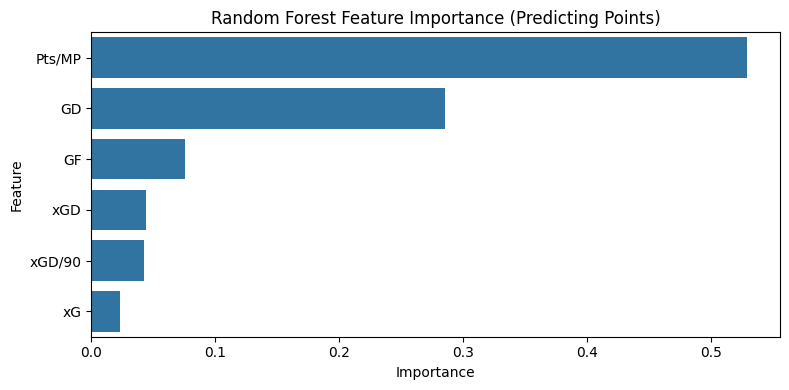

,feature,importance
2,Pts/MP,0.528799
1,GD,0.285361
0,GF,0.075671
4,xGD,0.044131
5,xGD/90,0.042543
3,xG,0.023496


In [ ]:
# Feature importance from the Random Forest regressor model
import seaborn as sns
import matplotlib.pyplot as plt

importances = model.feature_importances_
fi_df = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=fi_df, x="importance", y="feature")
plt.title("Random Forest Feature Importance (Predicting Points)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

fi_df

Practical use of model - Predicting week 14 standings:

In [ ]:
# Predict next round points for all teams based on most recent data (Dec 1) and display predicted rankings

# Update model training with most recent data
model.fit(x_test, y_actual)

def show_predicted_rankings():
    # Extract team names
    teams = test_df["Squad"]

    # Predict points using the updated trained model
    predicted_points = model.predict(test_df[features])

    # Build results table
    results = pd.DataFrame({
        "Predicted_Rank": range(len(teams)),
        "Squad": teams,
        "Predicted_Points": predicted_points
    })

    # Rank teams
    results["Predicted_Rank"] = results["Predicted_Points"].rank(ascending=False).astype(int)

    # Sort by predicted rank
    results = results.sort_values("Predicted_Rank")

    return results

print("Predicted rankings after 14 matches played:")
projected_table = show_predicted_rankings()
projected_table

Predicted rankings after 14 matches played:


,Predicted_Rank,Squad,Predicted_Points
0,1,Arsenal,27.946
1,2,Manchester City,24.938
2,3,Chelsea,24.230
3,4,Aston Villa,22.562
4,5,Brighton,21.860
5,6,Sunderland,21.510
6,7,Manchester Utd,21.102
7,8,Liverpool,21.086
8,9,Crystal Palace,19.946
9,10,Brentford,19.250


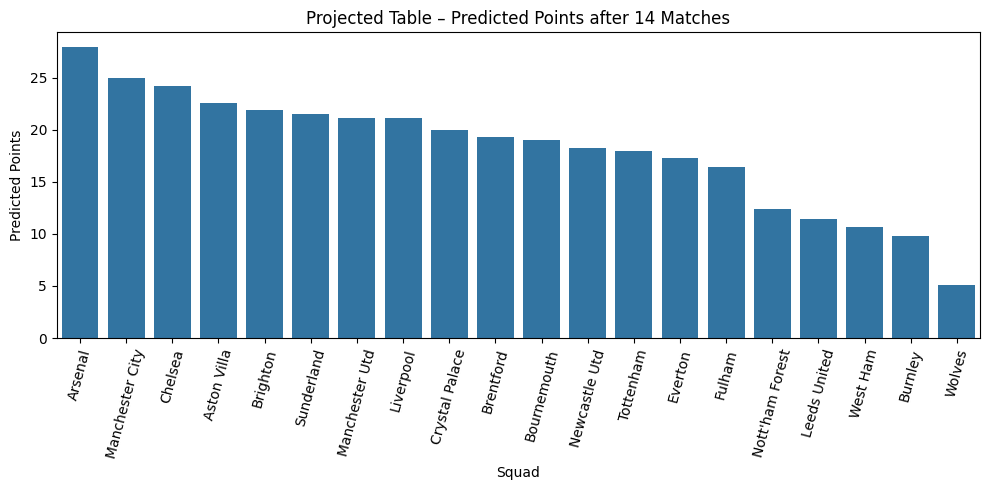

In [ ]:
# Bar plot of predicted points

plt.figure(figsize=(10, 5))
sns.barplot(data=projected_table, x="Squad", y="Predicted_Points")
plt.xticks(rotation=75)
plt.ylabel("Predicted Points")
plt.title("Projected Table – Predicted Points after 14 Matches")
plt.tight_layout()
plt.show()